In [113]:
%pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [114]:
#install packages

import plotly.express as px             #Api for Plotly Express
import plotly.graph_objects as go       #Api for Plotly Graph Objects
import pandas as pd                     #Api for data analysis and manipulation
import seaborn as sns                   #Api for statistical data visualization
import numpy as np                      #Api for numerical computing


In [115]:
# Loading afew dataset
#To see all the names of available datasets in seaborn
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [116]:
#Trying to read in the 'tips' dataset
df_tips = sns.load_dataset('tips')
df_health = sns.load_dataset('healthexp')
df_titanic = sns.load_dataset('titanic')

#This is an example of how to read in a dataset from a csv file
#To see the first  rows of the dataset
df_tips.head(n=10)
df_tips.tail(n=10)

,total_bill,tip,sex,smoker,day,time,size
234,15.53,3.00,Male,Yes,Sat,Dinner,2
235,10.07,1.25,Male,No,Sat,Dinner,2
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [117]:
df_health

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


In [118]:
df_health['Country'].unique()      # if correct spelling is 'country'

<StringArray>
['Germany', 'France', 'Great Britain', 'Japan', 'USA', 'Canada']
Length: 6, dtype: str

#### 1.Line chart
A line is used to show trends overtime

1. Understand the problem of what your are trying to plot
2. Organize the data to meet your desired end
3. Use the ploting API
4. Plot
5. Customize
6. Render 

In [119]:
# For example we want to visualize the life expectancy of Germany over the years.
country_filtered = ['Germany', 'France', 'Canada']  # List of countries to filter by

df_health_filtered = df_health[df_health['Country'].isin(country_filtered)]  # Filter the dataset to include only the specified country

# Plotly Express API
fig = px.line(
    data_frame=df_health_filtered,
    x='Year',  # Column to be plotted on the x-axis
    y='Life_Expectancy',
    markers=True,
    color='Country', #Does the coloring for the 3 countries
    title='Life Expectancy of Germany Over the Years',
    labels = {'Year': 'Year', 'Life_Expectancy': 'Life Expect'},
    template='plotly_white'
 )
fig.update_layout(title_font_size=20, title_font_color='brown', title_x=0.5)
fig.update_layout(hovermode='x unified')
fig.show()

#### 1.Bar Chart
 Used to do categorical comparison

In [120]:
df_health.groupby('Country')['Spending_USD'].mean().sort_values(ascending=False)

Country
USA              4388.570529
France           3045.145057
Canada           2685.778341
Germany          2667.280200
Great Britain    2034.192465
Japan            1860.257902
Name: Spending_USD, dtype: float64

In [121]:
average_spending = df_health.groupby('Country')['Spending_USD'].mean().sort_values(ascending=False)

# Add this one line:
average_spending = average_spending.reset_index()

fig = px.bar(
    data_frame=average_spending,
    x='Country',
    y='Spending_USD',
    title='Average spending on healthcare per country',
    template='plotly_white',
    labels={'Spending_USD': 'Average Spending (USD)'},
    color='Country',
    text_auto='.0f'

)
fig.update_layout(title_font_size=20, title_font_color='brown', title_x=0.5)
fig.show()

#### 1.Pie Chart
 Composition/Percentage distribution


In [122]:
#Pie chart on matlotlib and pandas
#df_tips['day'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue'])

#Python is case sensitive

In [123]:
day_counts = df_tips['day'].value_counts().reset_index()
day_counts

#Use API GO to crete a pie chart

fig =go.Figure(
    go.Pie(
        labels=day_counts['day'],
        values=day_counts['count'],
        hole=0.4,
        #textinfo='percent+label',

        
    ))

fig.update_layout(title='Distribution of Days in Tips Dataset', title_font_size=20, title_font_color='brown', title_x=0.5)
fig.update_traces(
    textposition='outside',
    textinfo='percent+label',
    hovertemplate='<b>%{label}: %{value} (%{percent})</b><extra></extra>'
)

fig.add_annotation(
    text=f"{df_tips.shape[0]} Bills",
    x=0.5, y=0.5,
    showarrow=False,
    font=dict(size=16, color='black')
)
fig.show()


Data Science has 3 broad categories
1. Descriptive Analytics - describe historical patterns
2. Diagnostics Analytics - Finding a solution to a problems
3. Predictive Analytics - ML
4. Prescriptive Analytics - for stragetic positioning

What are the fundamentals of data Analysis (what counts?)

  1. Understanding the business problem that you are solving eg why the sales of company ABC has declined in the last 3 months?
 Steps
  2. Collect the necessary data
 sales .. 1. Customer data 2.Product data 3. pricing data 4. supply data
 - Data is stored in db(inhouse) or cloud based eg AWS
 - Structured data
 - ETL
 3. Clean Data
 4. EDA
    1. Univariate Analyisis - Analyze one variable eg No of customer age
    2. Bivariate Analysis - Analyze 2 variables
    3. Multivariate Analysis - More than 3 variables
- Use of Statistical methods
  1. Measures of central tendancy(Center) <Mean, Median, Mode>
  2. Measures of dispersion(Spread) <Range, Variance, SD>
  3. Measures of position <Percentile, Quartiles, Z-Score>
  4. Meaure of shape <Skewness, Kurtosis>

  5. Hypothesis Testing

- Raw Analysis - Use pandas to do analysis without visualization

- Conclusion and Findings eg The customer acquisition in the last 3 months reduced by 30%
- Data driven decision is made eg Focus on acquiring new customers

5. KPIs eg Lets come up with with KPI to track customer acqusition
- Customer retention
- CAC
- Customer churn 

6. Data Dashboarding is necessary ie PowerBI, Dash and Plotly(is what we are doing)
7. Can you tell us based on historical info what will be the sales next month? ie Predictive analysis

In [124]:
df_tips.groupby('day', observed=False).agg(
    count=('total_bill', 'count'),
    mean_total_bill=('total_bill', 'mean'),
    med_total_bill=('total_bill', 'median'),
    min_total_bill=('total_bill', 'min'),
    max_total_bill=('total_bill', 'max'),
    std_total_bill=('total_bill', 'std')
).reset_index()

,day,count,mean_total_bill,med_total_bill,min_total_bill,max_total_bill,std_total_bill
0,Thur,62,17.682742,16.20,7.51,43.11,7.886170
1,Fri,19,17.151579,15.38,5.75,40.17,8.302660
2,Sat,87,20.441379,18.24,3.07,50.81,9.480419
3,Sun,76,21.410000,19.63,7.25,48.17,8.832122


<Axes: ylabel='total_bill'>

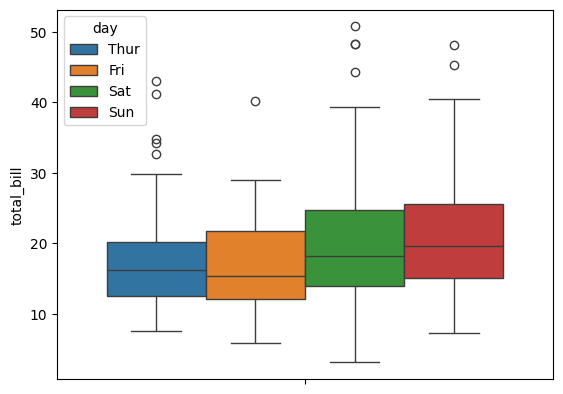

In [125]:
sns.boxplot(data=df_tips, y='total_bill', hue='day')

<Axes: ylabel='total_bill'>

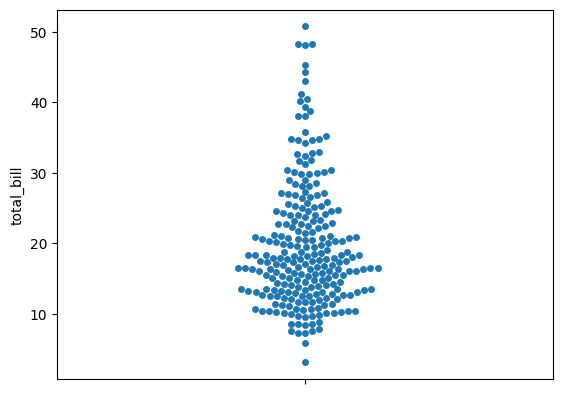

In [126]:
sns.swarmplot(data=df_tips, y='total_bill')

<Axes: xlabel='total_bill', ylabel='tip'>

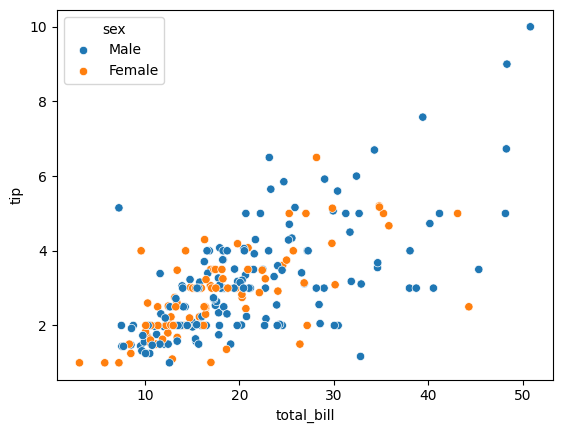

In [127]:
sns.scatterplot(data=df_tips, x='total_bill', y='tip', hue='sex')

#### Box Plots

In [128]:
fig = px.box(
    df_tips,
    x='day',
    y='total_bill',
    color='sex',
    labels = {'day': 'Day of the Week', 'total_bill': 'Total Bill ($)'},
    title='Restaurant Bill Distribution by Day and Gender'
)

fig.show()

In [129]:
fig = px.violin(
    df_tips,
    x='day',
    y='total_bill',
    color='sex',
    labels = {'day': 'Day of the Week', 'total_bill': 'Total Bill ($)'},
    title='Restaurant Bill Distribution by Day and Gender'
)

fig.show()

#### Histogram

In [130]:
fig = px.histogram(
    data_frame=df_titanic,
    x='age',
    marginal='box',
    title='Age Distribution of Titanic Passengers',
    barmode='overlay', # overlay for the histogram bars to show the distribution age of survived and not survived passengers
    color='survived',
    nbins=30,
    labels={'count': 'Count: Frequency of Passengers', 'age': 'Age (years)'},
    template='plotly_white'
)
fig.add_vline(x=df_titanic['age'].mean(), line_dash='dash', line_color='red', annotation_text='Mean Age', annotation_position='top left')

fig.show()

#### Heatmaps

In [131]:
if 'df_iris' not in globals():
    df_iris = sns.load_dataset('iris')

df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [132]:
# Build correlation matrix first
corr_matrix = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].corr()

# Create heatmap figure and assign it to `fig`
fig = go.Figure(
    go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns,
        y=corr_matrix.index,
        text=corr_matrix.round(2).values,
        texttemplate='%{text}',  # Display the correlation values on the heatmap
        textfont={'size': 12, 'color': 'black'},
        colorscale='rdbu',
        zmin=-1,
        zmax=1,
        colorbar=dict(title='Correlation Coefficient')
    )
)
fig.update_layout(title='Correlation Heatmap of Iris Dataset', title_font_size=20, title_font_color='brown', title_x=0.5)
fig.show()

In [133]:
df_flights = sns.load_dataset('flights')
df_flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [134]:
pivot = df_flights.pivot(index='month', columns='year', values='passengers')

fig = px.imshow(
    pivot,
    text_auto=True,
    labels={'x': 'Year', 'y': 'Month', 'color': 'Passengers'},
    title='Flight Passengers Heatmap',
    aspect='auto'
)
fig.update_layout(width=800, height=600, title_font_size=20, title_font_color='brown', title_x=0.5)
fig.show()

In [135]:
fig =px.scatter_3d(
    df_iris,
    x='sepal_length',
    y='petal_length',
    z='petal_width',
    color='species',
    title='3D Scatter Plot of Iris Dataset',
    labels={'sepal_length': 'Sepal Length (cm)', 'sepal_width': 'Sepal Width (cm)', 'petal_length': 'Petal Length (cm)'},
    template='plotly_white'
)
fig.update_layout(title_font_size=20, title_font_color='brown', title_x=0.5)

fig.show()

In [136]:
fig =px.scatter(
    df_health,
    x='Spending_USD',
    y='Life_Expectancy',
    animation_frame='Year',
    animation_group='Country',
    size='Spending_USD',
    color='Country',
    size_max=50,
    range_x=[0, df_health['Spending_USD'].max() * 1.1],
    range_y = [60,90],
    title='Healthcare Spending vs Life Expectancy Over Time',
)
fig.layout.update(updatemenus=[dict(type='buttons', showactive=False, y=1, x=1.1, xanchor='right', yanchor='top')])
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 600
fig.show()

## Scenario Story: When do customers tip the most, and what drives tipping behaviour?

This section builds three charts from the `tips` dataset and records key findings.

In [137]:
# Shared preparation
# Keep day order consistent with the business question
plot_days = ['Thur', 'Fri', 'Sat', 'Sun']

# Add tip percentage once for later analysis
df_tips = df_tips.copy()
df_tips['tip_pct'] = (df_tips['tip'] / df_tips['total_bill']) * 100

In [138]:
# Chart 1: Grouped bar chart for average total bill and average tip by day
chart1_df = (
    df_tips.groupby('day', observed=False)
    .agg(avg_total_bill=('total_bill', 'mean'), avg_tip=('tip', 'mean'))
    .reindex(plot_days)
    .reset_index()
)

fig1 = px.bar(
    chart1_df,
    x='day',
    y=['avg_total_bill', 'avg_tip'],
    barmode='group',
    labels={
        'day': 'Day of Week',
        'value': 'Average Amount (USD)',
        'variable': 'Metric'
    },
    title='Average Total Bill and Tip by Day',
    template='plotly_white'
)

overall_avg_tip = df_tips['tip'].mean()
fig1.add_hline(
    y=overall_avg_tip,
    line_dash='dash',
    line_color='firebrick',
    annotation_text=f'Overall Avg Tip: {overall_avg_tip:.2f}',
    annotation_position='top right'
)

fig1.show()

In [140]:
# Chart 2: Scatter plot of total bill vs tip with OLS trendline
# If trendline errors, run: pip install statsmodels
fig2 = px.scatter(
    df_tips,
    x='total_bill',
    y='tip',
    color='time',
    size='size',
    hover_data={
        'tip_pct': ':.2f',
        'day': True,
        'smoker': True,
        'total_bill': ':.2f',
        'tip': ':.2f'
    },
    labels={'total_bill': 'Total Bill (USD)', 'tip': 'Tip (USD)'},
    title='Do Bigger Bills Lead to Bigger Tips?'
)
fig2.show()

In [141]:
# Chart 3: Side-by-side donut charts (sex and smoker)
from plotly.subplots import make_subplots

sex_counts = df_tips['sex'].value_counts()
smoker_counts = df_tips['smoker'].value_counts()

fig3 = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=('Bills by Customer Sex', 'Bills by Smoker Status')
)

fig3.add_trace(
    go.Pie(labels=sex_counts.index, values=sex_counts.values, hole=0.45, name='Sex'),
    row=1,
    col=1
)
fig3.add_trace(
    go.Pie(labels=smoker_counts.index, values=smoker_counts.values, hole=0.45, name='Smoker'),
    row=1,
    col=2
)

fig3.update_layout(
    title='Who Are the Customers? Bill Count by Sex and Smoker Status',
    title_x=0.5
)

fig3.show()

In [142]:
# Required findings summary
# 1) Highest average tip day
highest_avg_tip_day = chart1_df.loc[chart1_df['avg_tip'].idxmax(), 'day']

# 2) Lowest tip percentage day (average tip_pct)
lowest_tip_pct_day = (
    df_tips.groupby('day', observed=False)['tip_pct']
    .mean()
    .reindex(plot_days)
    .idxmin()
)

# 3) Correlation between bill amount and tip
bill_tip_corr = df_tips['total_bill'].corr(df_tips['tip'])

# 4) Lunch vs Dinner higher average tip
avg_tip_by_time = df_tips.groupby('time', observed=False)['tip'].mean()
higher_time = avg_tip_by_time.idxmax()

print(f'Highest average tip day: {highest_avg_tip_day}')
print(f'Lowest tip percentage day: {lowest_tip_pct_day}')
print(f'Correlation (total_bill vs tip): {bill_tip_corr:.3f}')
print('Average tip by time:')
print(avg_tip_by_time.round(3))
print(f'Higher average tips come from: {higher_time}')

Highest average tip day: Sun
Lowest tip percentage day: Sat
Correlation (total_bill vs tip): 0.676
Average tip by time:
time
Lunch     2.728
Dinner    3.103
Name: tip, dtype: float64
Higher average tips come from: Dinner
